In [3]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0]

print(f'Węzły: {data.num_nodes}')
print(f'Krawędzie: {data.num_edges}')
print(f'Cechy węzła: {data.num_node_features}')
print(f'Klas: {dataset.num_classes}')
print(f'Węzły treningowe: {data.train_mask.sum()}')

Processing...


Węzły: 2708
Krawędzie: 10556
Cechy węzła: 1433
Klas: 7
Węzły treningowe: 140


Done!


# Baseline GCN implementation

In [4]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

### GCN training

In [5]:
model = GCN(dataset.num_features, 64, dataset.num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss

def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

for epoch in range(200):
    loss = train()
    acc = test()
    if epoch % 20 == 0:
        print(f'Epoch {epoch}: Loss={loss:.4f}, Acc={acc:.4f}')

Epoch 0: Loss=1.9638, Acc=0.5090
Epoch 20: Loss=0.0146, Acc=0.7850
Epoch 40: Loss=0.0011, Acc=0.7720
Epoch 60: Loss=0.0007, Acc=0.7780
Epoch 80: Loss=0.0011, Acc=0.7770
Epoch 100: Loss=0.0003, Acc=0.7730
Epoch 120: Loss=0.0003, Acc=0.7720
Epoch 140: Loss=0.0003, Acc=0.7770
Epoch 160: Loss=0.0002, Acc=0.7800
Epoch 180: Loss=0.0004, Acc=0.7780


# Create split

In [7]:
import torch
import numpy as np
from collections import defaultdict

def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)

    available_indices = (~data.test_mask).nonzero(as_tuple=True)[0]

    train_size = int(data.num_nodes * label_ratio)
    shuffled = available_indices[torch.randperm(len(available_indices))]

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[shuffled[:train_size]] = True

    return train_mask

# Uruchomienie każdego scenariusza 5 razy z różnym seedem
ratios = [0.05, 0.10, 0.20]
seeds = [42, 123, 456, 789, 1000]
results = defaultdict(list)

for ratio in ratios:
    for seed in seeds:
        data.train_mask = create_split(data, ratio, seed)
        
        model = GCN(dataset.num_features, 64, dataset.num_classes)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        
        for epoch in range(200):
            train()
        
        acc = test()
        results[ratio].append(acc)
        print(f'Ratio: {ratio:.0%}, Seed: {seed}, Acc: {acc:.4f}')

for ratio, accs in results.items():
    mean = np.mean(accs)
    std = np.std(accs)
    print(f'{ratio:.0%}: {mean:.4f} ± {std:.4f}')

Ratio: 5%, Seed: 42, Acc: 0.7900
Ratio: 5%, Seed: 123, Acc: 0.7980
Ratio: 5%, Seed: 456, Acc: 0.7750
Ratio: 5%, Seed: 789, Acc: 0.8170
Ratio: 5%, Seed: 1000, Acc: 0.7810
Ratio: 10%, Seed: 42, Acc: 0.8100
Ratio: 10%, Seed: 123, Acc: 0.7910
Ratio: 10%, Seed: 456, Acc: 0.8290
Ratio: 10%, Seed: 789, Acc: 0.8160
Ratio: 10%, Seed: 1000, Acc: 0.8300
Ratio: 20%, Seed: 42, Acc: 0.8410
Ratio: 20%, Seed: 123, Acc: 0.8060
Ratio: 20%, Seed: 456, Acc: 0.8340
Ratio: 20%, Seed: 789, Acc: 0.8140
Ratio: 20%, Seed: 1000, Acc: 0.8420
5%: 0.7922 ± 0.0147
10%: 0.8152 ± 0.0143
20%: 0.8274 ± 0.0147


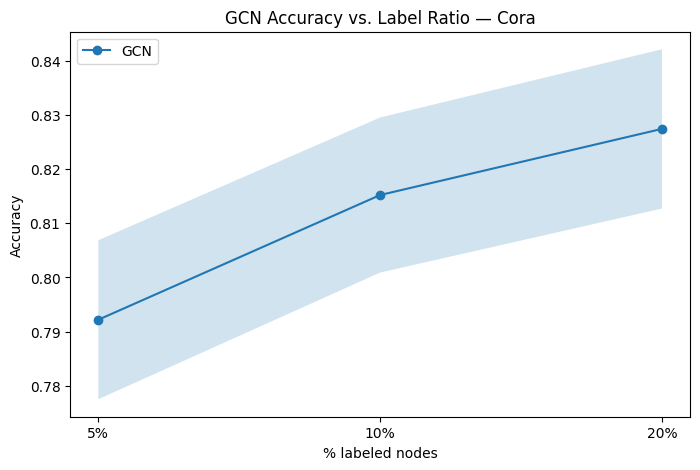

In [10]:
import matplotlib.pyplot as plt

means = [np.mean(results[r]) for r in ratios]
stds = [np.std(results[r]) for r in ratios]
labels = ['5%', '10%', '20%']

plt.figure(figsize=(8, 5))
plt.plot(labels, means, marker='o', label='GCN')
plt.fill_between(labels, 
                 [m-s for m,s in zip(means,stds)],
                 [m+s for m,s in zip(means,stds)], 
                 alpha=0.2)
plt.xlabel('% labeled nodes')
plt.ylabel('Accuracy')
plt.title('GCN Accuracy vs. Label Ratio — Cora')
plt.legend()
import os
os.makedirs('results', exist_ok=True)
plt.savefig('results/gcn_label_ratio.png')
plt.show()